In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/02_nav_history.csv"
)

nav['date'] = pd.to_datetime(nav['date'])

print(nav.shape)
nav.head()

(46000, 3)


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [2]:
nav = nav.sort_values(
    ['amfi_code', 'date']
)

nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


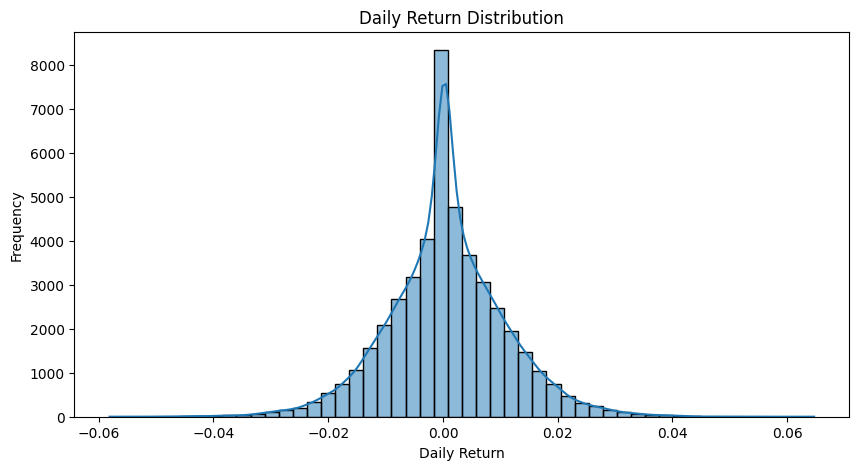

In [3]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav['daily_return'].dropna(),
    bins=50,
    kde=True
)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [4]:
print(
    nav['daily_return'].describe()
)

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


In [5]:
def calculate_cagr(start_value, end_value, years):
    return (end_value / start_value) ** (1 / years) - 1

In [6]:
nav = nav.sort_values(['amfi_code', 'date'])

In [7]:
cagr_df = nav.groupby('amfi_code').agg(
    start_nav=('nav', 'first'),
    end_nav=('nav', 'last'),
    start_date=('date', 'first'),
    end_date=('date', 'last')
).reset_index()

cagr_df.head()

,amfi_code,start_nav,end_nav,start_date,end_date
0,100016,520.4608,583.6113,2022-01-03,2026-05-29
1,100025,26.3169,31.8843,2022-01-03,2026-05-29
2,100033,107.3758,342.0072,2022-01-03,2026-05-29
3,101206,305.0996,773.2939,2022-01-03,2026-05-29
4,101207,38.5736,53.9836,2022-01-03,2026-05-29


In [11]:
cagr_df['years'] = (
    (cagr_df['end_date'] - cagr_df['start_date']).dt.days / 365
)


In [9]:
cagr_df['cagr'] = calculate_cagr(
    cagr_df['start_nav'],
    cagr_df['end_nav'],
    cagr_df['years']
)

cagr_df[['amfi_code', 'cagr']].head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [12]:
risk_free_rate = 0.065  # 6.5%

sharpe_df = nav.groupby('amfi_code')['daily_return'].agg(['mean','std']).reset_index()

sharpe_df['sharpe'] = (
    (sharpe_df['mean'] - risk_free_rate/252) /
    sharpe_df['std']
) * np.sqrt(252)

sharpe_df.head()

,amfi_code,mean,std,sharpe
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [13]:
final_df = cagr_df.merge(sharpe_df, on='amfi_code')

final_df['rank_cagr'] = final_df['cagr'].rank(ascending=False)
final_df['rank_sharpe'] = final_df['sharpe'].rank(ascending=False)

final_df.head()

,amfi_code,start_nav,end_nav,start_date,end_date,years,cagr,mean,std,sharpe,rank_cagr,rank_sharpe
0,100016,520.4608,583.6113,2022-01-03,2026-05-29,4.40274,0.026352,0.000142,0.009164,-0.201517,37.0,35.0
1,100025,26.3169,31.8843,2022-01-03,2026-05-29,4.40274,0.044551,0.000170,0.002460,-0.567095,36.0,39.0
2,100033,107.3758,342.0072,2022-01-03,2026-05-29,4.40274,0.300997,0.001080,0.011929,1.093699,7.0,7.0
3,101206,305.0996,773.2939,2022-01-03,2026-05-29,4.40274,0.235205,0.000852,0.009177,1.027213,12.0,9.0
4,101207,38.5736,53.9836,2022-01-03,2026-05-29,4.40274,0.079331,0.000424,0.016251,0.162661,27.0,28.0


In [14]:
downside = nav[nav['daily_return'] < 0]

sortino_df = nav.groupby('amfi_code')['daily_return'].agg(['mean']).reset_index()

down_std = downside.groupby('amfi_code')['daily_return'].std().reset_index()
down_std.columns = ['amfi_code', 'down_std']

sortino_df = sortino_df.merge(down_std, on='amfi_code', how='left')

risk_free = 0.065 / 252

sortino_df['sortino'] = (
    (sortino_df['mean'] - risk_free) / sortino_df['down_std']
) * np.sqrt(252)

sortino_df.head()

,amfi_code,mean,down_std,sortino
0,100016,0.000142,0.005261,-0.351047
1,100025,0.000170,0.001481,-0.941821
2,100033,0.001080,0.007133,1.829134
3,101206,0.000852,0.005238,1.799563
4,101207,0.000424,0.009555,0.276644


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav = pd.read_csv(
    "C:/Users/shivj/OneDrive/Desktop/bluestock_mf_capstone/data/Raw/02_nav_history.csv"
)

nav['date'] = pd.to_datetime(nav['date'])

In [19]:
nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

In [20]:
cagr_df = nav.groupby('amfi_code').agg(
    start_nav=('nav','first'),
    end_nav=('nav','last')
).reset_index()

cagr_df['cagr'] = (cagr_df['end_nav']/cagr_df['start_nav'])**(1/4.4)-1

In [21]:
sharpe_df = nav.groupby('amfi_code')['daily_return'].agg(['mean','std']).reset_index()

sharpe_df['sharpe'] = (sharpe_df['mean']/sharpe_df['std'])*np.sqrt(252)

In [22]:
downside = nav[nav['daily_return'] < 0]

down_std = downside.groupby('amfi_code')['daily_return'].std().reset_index()
down_std.columns = ['amfi_code','down_std']

sortino_df = nav.groupby('amfi_code')['daily_return'].mean().reset_index()

sortino_df = sortino_df.merge(down_std,on='amfi_code',how='left')

sortino_df['sortino'] = (sortino_df['daily_return']/sortino_df['down_std'])*np.sqrt(252)

In [23]:
nav['cum_max'] = nav.groupby('amfi_code')['nav'].cummax()
nav['drawdown'] = nav['nav']/nav['cum_max'] - 1

max_dd = nav.groupby('amfi_code')['drawdown'].min().reset_index()
max_dd.columns = ['amfi_code','max_drawdown']

In [24]:
final_metrics = cagr_df.merge(sharpe_df,on='amfi_code')
final_metrics = final_metrics.merge(sortino_df[['amfi_code','sortino']],on='amfi_code')
final_metrics = final_metrics.merge(max_dd,on='amfi_code')

In [25]:
score_df = final_metrics.copy()

score_df['score'] = (
    (score_df['cagr'].rank(ascending=False)*0.30) +
    (score_df['sharpe'].rank(ascending=False)*0.25) +
    (score_df['sortino'].rank(ascending=False)*0.20) +
    (score_df['max_drawdown'].rank(ascending=True)*0.15)
)

score_df['score'] = 100 - (score_df['score']/score_df['score'].max()*100)

score_df.sort_values('score',ascending=False).head()

,amfi_code,start_nav,end_nav,cagr,mean,std,sharpe,sortino,max_drawdown,score
25,120505,135.8720,473.7640,0.328251,0.001161,0.012152,1.517047,2.608779,-0.181885,78.155340
36,148569,28.8620,97.7435,0.319472,0.001124,0.011134,1.602702,2.786282,-0.163967,76.213592
34,148567,70.2514,230.2708,0.309719,0.001074,0.008941,1.906241,3.139985,-0.112657,73.300971
30,120843,49.9131,163.2397,0.309053,0.001082,0.010008,1.715884,3.104586,-0.129740,73.300971
19,119551,54.3856,149.3216,0.258029,0.000917,0.008656,1.681289,2.978156,-0.150124,69.902913


In [26]:
nifty = nav.groupby('date')['daily_return'].mean().reset_index()
nifty.columns = ['date','nifty_return']

In [27]:
merged = nav.merge(nifty, on='date', how='left')
merged = merged.dropna()

In [28]:
from scipy import stats

alpha_beta_list = []

for code in merged['amfi_code'].unique():
    df = merged[merged['amfi_code'] == code]

    beta, alpha, r, p, se = stats.linregress(
        df['nifty_return'],
        df['daily_return']
    )

    alpha_beta_list.append([code, alpha*252, beta])

alpha_beta_df = pd.DataFrame(alpha_beta_list, columns=[
    'amfi_code','alpha','beta'
])

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,-0.089699,0.788441
1,100025,0.033199,0.060713
2,100033,0.114423,0.991590
3,101206,0.097443,0.737015
4,101207,-0.350741,2.878184


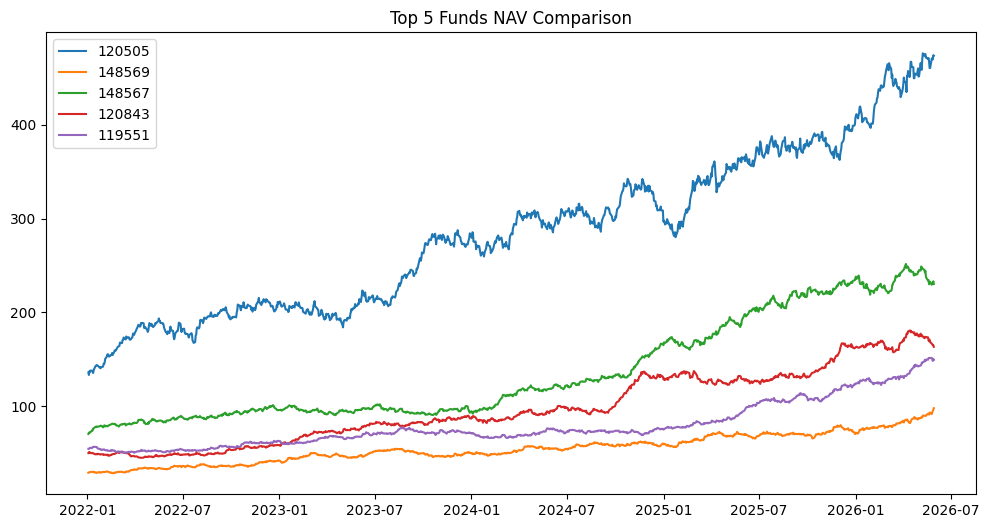

In [29]:
top5 = score_df.sort_values('score', ascending=False).head(5)

top5_data = nav[nav['amfi_code'].isin(top5['amfi_code'])]

plt.figure(figsize=(12,6))

for code in top5['amfi_code']:
    temp = top5_data[top5_data['amfi_code']==code]
    temp = temp.groupby('date')['nav'].mean()
    plt.plot(temp.index, temp.values, label=str(code))

plt.legend()
plt.title("Top 5 Funds NAV Comparison")
plt.show()

In [30]:
score_df.to_csv("../data/processed/fund_scorecard.csv", index=False)
alpha_beta_df.to_csv("../data/processed/alpha_beta.csv", index=False)

In [31]:
nifty = nav.groupby('date')['daily_return'].mean().reset_index()
nifty.columns = ['date', 'nifty_return']

In [32]:
merged = nav.merge(nifty, on='date', how='left')
merged = merged.dropna()

In [33]:
from scipy import stats
import pandas as pd

alpha_beta_list = []

for code in merged['amfi_code'].unique():
    df = merged[merged['amfi_code'] == code]

    beta, alpha, r, p, se = stats.linregress(
        df['nifty_return'],
        df['daily_return']
    )

    alpha_beta_list.append([
        code,
        alpha * 252,   # annualized alpha
        beta
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta_list,
    columns=['amfi_code', 'alpha', 'beta']
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,-0.089699,0.788441
1,100025,0.033199,0.060713
2,100033,0.114423,0.991590
3,101206,0.097443,0.737015
4,101207,-0.350741,2.878184


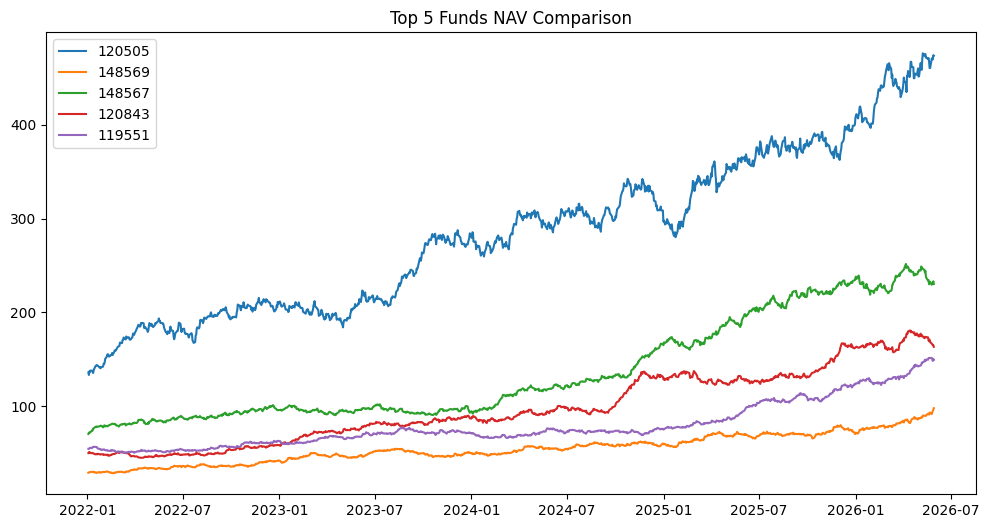

In [34]:
top5 = score_df.sort_values('score', ascending=False).head(5)

top5_nav = nav[nav['amfi_code'].isin(top5['amfi_code'])]

plt.figure(figsize=(12,6))

for code in top5['amfi_code']:
    temp = top5_nav[top5_nav['amfi_code'] == code]
    temp = temp.groupby('date')['nav'].mean()
    plt.plot(temp.index, temp.values, label=str(code))

plt.title("Top 5 Funds NAV Comparison")
plt.legend()
plt.show()

In [35]:
score_df.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)